In [ ]:
# Importing required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

sep=';' is used because the Kaggle Cardiovascular dataset uses semicolons
instead of commas to separate values; without this, the data would load as a single broken column.
df = pd.read_csv('cardio_train.csv', sep=';')

In [ ]:
# 1. Load Data
df = pd.read_csv('cardio_train.csv', sep=';')


In [ ]:
# Display the first few rows of the dataset
df.head()



,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [ ]:
# Summary statistics for numerical columns
print("\nSummary statistics:")
print(df.describe())





Summary statistics:
                 id           age        gender        height        weight  \
count  70000.000000  70000.000000  70000.000000  70000.000000  70000.000000   
mean   49972.419900  19468.865814      1.349571    164.359229     74.205690   
std    28851.302323   2467.251667      0.476838      8.210126     14.395757   
min        0.000000  10798.000000      1.000000     55.000000     10.000000   
25%    25006.750000  17664.000000      1.000000    159.000000     65.000000   
50%    50001.500000  19703.000000      1.000000    165.000000     72.000000   
75%    74889.250000  21327.000000      2.000000    170.000000     82.000000   
max    99999.000000  23713.000000      2.000000    250.000000    200.000000   

              ap_hi         ap_lo   cholesterol          gluc         smoke  \
count  70000.000000  70000.000000  70000.000000  70000.000000  70000.000000   
mean     128.817286     96.630414      1.366871      1.226457      0.088129   
std      154.011419    188.472

In [ ]:
df.dtypes


,0
id,int64
age,int64
gender,int64
height,int64
weight,float64
ap_hi,int64
ap_lo,int64
cholesterol,int64
gluc,int64
smoke,int64


In a real-world healthcare setting, doctors diagnose risk based on years, not days.
This is done to align the feature with clinical standards and ensure the model
isn't confused by large numerical ranges.

In [ ]:
# Convert age from days to years
df['age'] = (df['age'] / 365).round().astype(int)

Checking of missing values is necessary because Mathematical models cannot perform operations like calculating a mean or a gradient on non-existent data. Checking for nulls tells one if there is need to perform "Imputation".
In a cardio dataset of 70,000 records, missing values in columns like Blood Pressure would suggest an error in the data collection process. Verifying that the sum is zero for all columns confirms that the dataset is "clean" and ready for feature engineering.

In [ ]:
# Checking for missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


In [ ]:
# Using SimpleImputer to fill missing values (if any) with the median for numerical columns
imputer = SimpleImputer(strategy='median')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

Exploratory Data Analysis

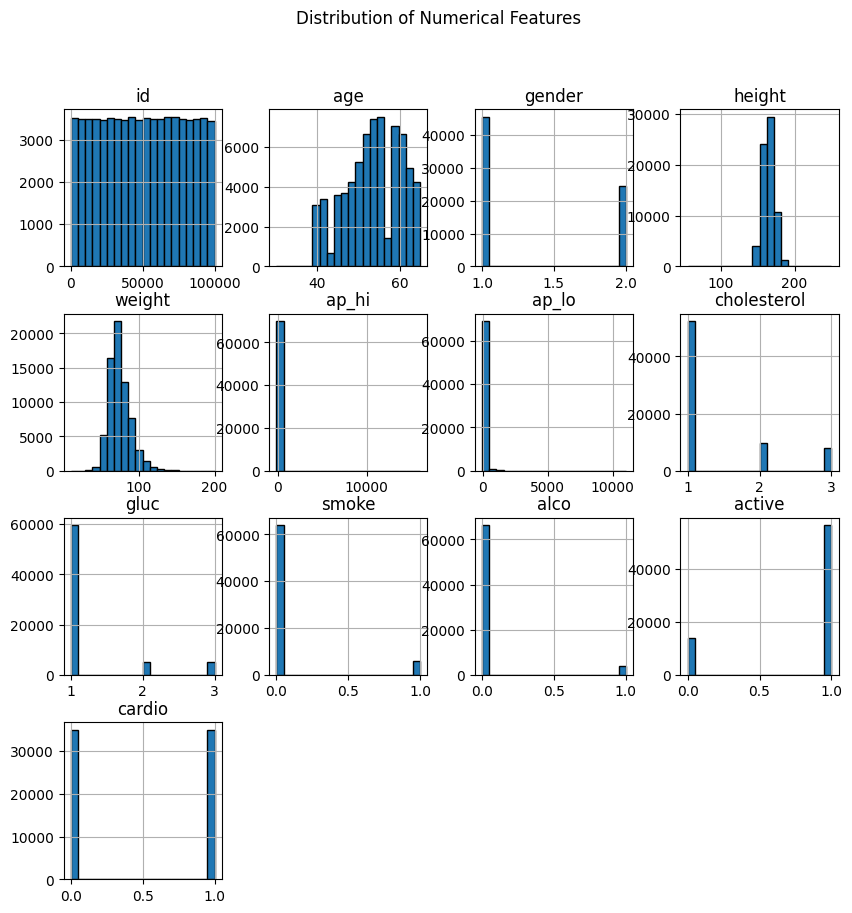

In [ ]:
# Visualizing the distribution of numerical features
df.hist(figsize=(10, 10), bins=20, edgecolor='black')
plt.suptitle("Distribution of Numerical Features")
plt.show()

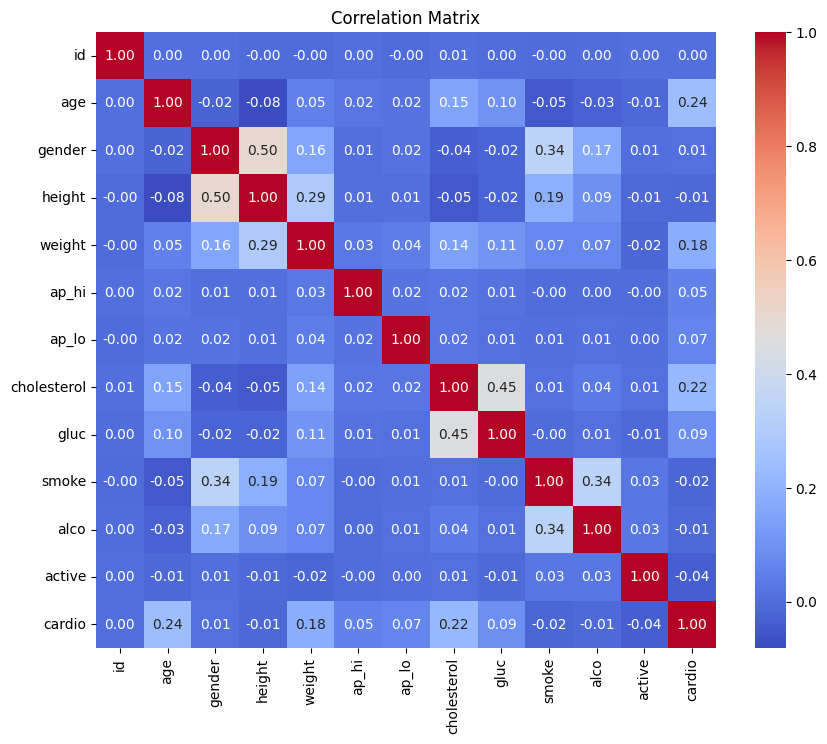

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

Handling Outliers

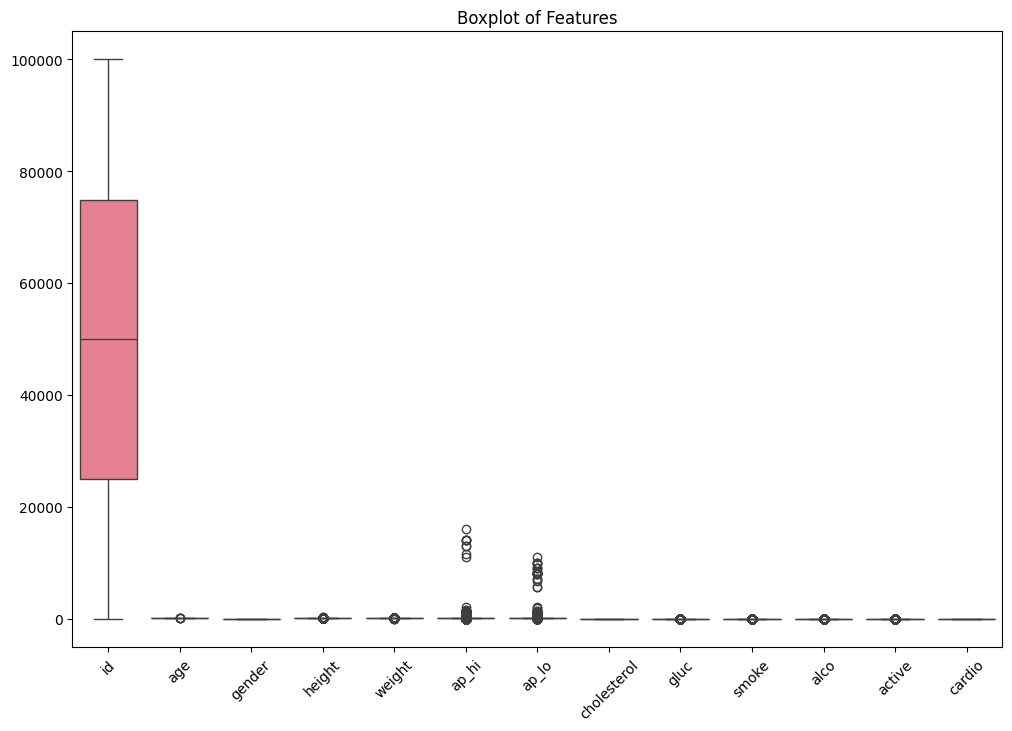

In [ ]:
# Boxplot to check for outliers
plt.figure(figsize=(12, 8))
sns.boxplot(data=df)
plt.title("Boxplot of Features")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Calculate IQR for each numeric column
Q1 = df_imputed.quantile(0.25)
Q3 = df_imputed.quantile(0.75)
IQR = Q3 - Q1

# Define outlier condition for each column
outlier_condition = ((df_imputed < (Q1 - 1.5 * IQR)) | (df_imputed > (Q3 + 1.5 * IQR)))

# Keep rows where no outliers are detected
df_no_outliers = df_imputed[~outlier_condition.any(axis=1)]

print(f"Dataset shape after outlier removal: {df_no_outliers.shape}")

Dataset shape after outlier removal: (38023, 13)


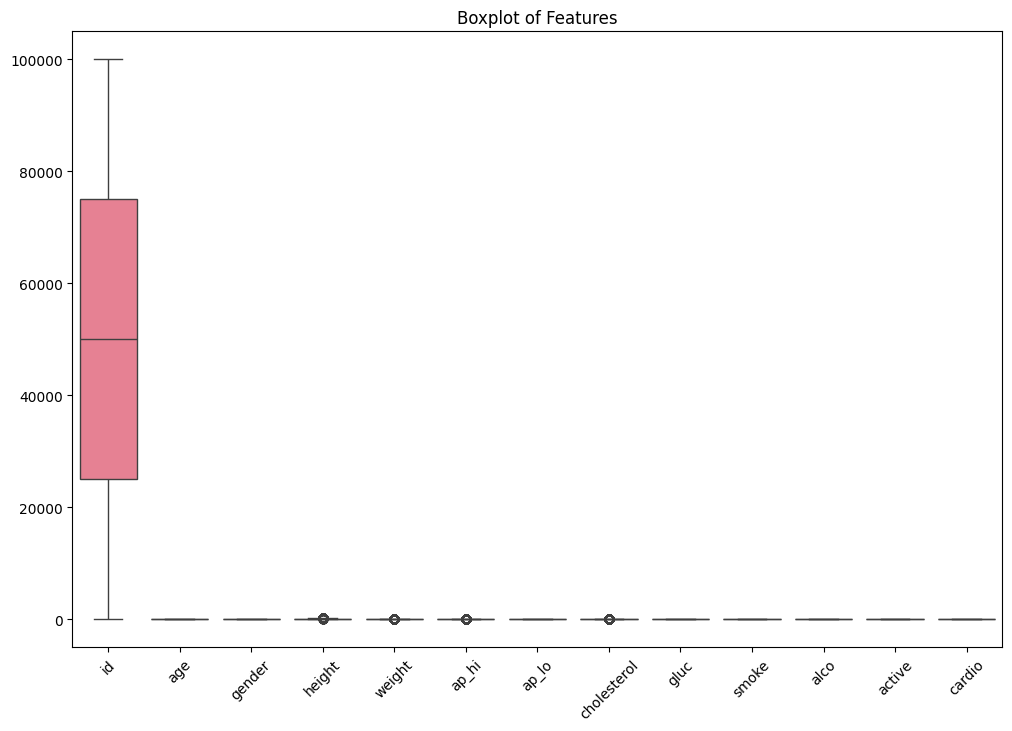

In [ ]:
# Boxplot to check for outliers
plt.figure(figsize=(12, 8))
sns.boxplot(data=df_no_outliers)
plt.title("Boxplot of Features")
plt.xticks(rotation=45)
plt.show()

Feature Engineering

In [ ]:
# First create an explicit copy of the dataframe
df_no_outliers = df_no_outliers.copy()

# Define the categorization functions
def categorize_age(age):
    if age < 21:
        return 'Young'
    elif age < 35:
        return 'Adult'
    else:
        return 'Middle_Aged'

def categorize_bmi(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

# Calculate BMI
df_no_outliers.loc[:, 'BMI'] = df_no_outliers['weight'] / ((df_no_outliers['height'] / 100)**2)

# Add new features using .loc
df_no_outliers.loc[:, 'Age_Category'] = df_no_outliers['age'].apply(categorize_age)
df_no_outliers.loc[:, 'BMI_Category'] = df_no_outliers['BMI'].apply(categorize_bmi)

# Convert to categorical
df_no_outliers.loc[:, 'Age_Category'] = df_no_outliers['Age_Category'].astype('category')
df_no_outliers.loc[:, 'BMI_Category'] = df_no_outliers['BMI_Category'].astype('category')

In [ ]:
df_no_outliers.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI,Age_Category,BMI_Category
0,0.0,50.0,2.0,168.0,62.0,110.0,80.0,1.0,1.0,0.0,0.0,1.0,0.0,21.967120,Middle_Aged,Normal
1,1.0,55.0,1.0,156.0,85.0,140.0,90.0,3.0,1.0,0.0,0.0,1.0,1.0,34.927679,Middle_Aged,Obese
3,3.0,48.0,2.0,169.0,82.0,150.0,100.0,1.0,1.0,0.0,0.0,1.0,1.0,28.710479,Middle_Aged,Overweight
6,9.0,61.0,1.0,157.0,93.0,130.0,80.0,3.0,1.0,0.0,0.0,1.0,0.0,37.729725,Middle_Aged,Obese
8,13.0,48.0,1.0,158.0,71.0,110.0,70.0,1.0,1.0,0.0,0.0,1.0,0.0,28.440955,Middle_Aged,Overweight


Encoding Categorical Variables

In [ ]:
# Method 2: One-Hot Encoding
df_encoded = pd.get_dummies(df_no_outliers,
                          columns=['Age_Category', 'BMI_Category'],
                          prefix=['Age', 'BMI'])

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Create label encoders
le_age = LabelEncoder()
le_bmi = LabelEncoder()

# Apply label encoding
df_no_outliers.loc[:, 'Age_Category_Label'] = le_age.fit_transform(df_no_outliers['Age_Category'])
df_no_outliers.loc[:, 'BMI_Category_Label'] = le_bmi.fit_transform(df_no_outliers['BMI_Category'])

In [ ]:
df_no_outliers.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI,Age_Category,BMI_Category,Age_Category_Label,BMI_Category_Label
0,0.0,50.0,2.0,168.0,62.0,110.0,80.0,1.0,1.0,0.0,0.0,1.0,0.0,21.967120,Middle_Aged,Normal,0,0
1,1.0,55.0,1.0,156.0,85.0,140.0,90.0,3.0,1.0,0.0,0.0,1.0,1.0,34.927679,Middle_Aged,Obese,0,1
3,3.0,48.0,2.0,169.0,82.0,150.0,100.0,1.0,1.0,0.0,0.0,1.0,1.0,28.710479,Middle_Aged,Overweight,0,2
6,9.0,61.0,1.0,157.0,93.0,130.0,80.0,3.0,1.0,0.0,0.0,1.0,0.0,37.729725,Middle_Aged,Obese,0,1
8,13.0,48.0,1.0,158.0,71.0,110.0,70.0,1.0,1.0,0.0,0.0,1.0,0.0,28.440955,Middle_Aged,Overweight,0,2


Scaling the data

In [ ]:
from sklearn.preprocessing import StandardScaler

# Select numeric columns to scale (excluding Outcome and one-hot encoded columns)
numeric_columns = ['age', 'height', 'weight', 'ap_hi', 'ap_lo', 'BMI']

# Create a scaler object
scaler = StandardScaler()

# Create a copy of the dataframe to store scaled values
df_scaled = df_encoded.copy()

# Fit and transform the selected numeric columns
df_scaled[numeric_columns] = scaler.fit_transform(df_scaled[numeric_columns])

# Verify the scaling by showing the head of the dataframe
df_scaled.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI,Age_Middle_Aged,BMI_Normal,BMI_Obese,BMI_Overweight,BMI_Underweight
0,0.0,-0.484135,2.0,0.550057,-0.854197,-1.114585,-0.180601,1.0,1.0,0.0,0.0,1.0,0.0,-1.103477,True,True,False,False,False
1,1.0,0.258553,1.0,-1.076354,1.058696,1.012872,1.137335,3.0,1.0,0.0,0.0,1.0,1.0,1.776741,True,False,True,False,False
3,3.0,-0.781210,2.0,0.685592,0.809188,1.722024,2.455271,1.0,1.0,0.0,0.0,1.0,1.0,0.395096,True,False,False,True,False
6,9.0,1.149779,1.0,-0.940819,1.724050,0.303720,-0.180601,3.0,1.0,0.0,0.0,1.0,0.0,2.399438,True,False,True,False,False
8,13.0,-0.781210,1.0,-0.805285,-0.105674,-1.114585,-1.498537,1.0,1.0,0.0,0.0,1.0,0.0,0.335200,True,False,False,True,False


Box plot for features after scaling

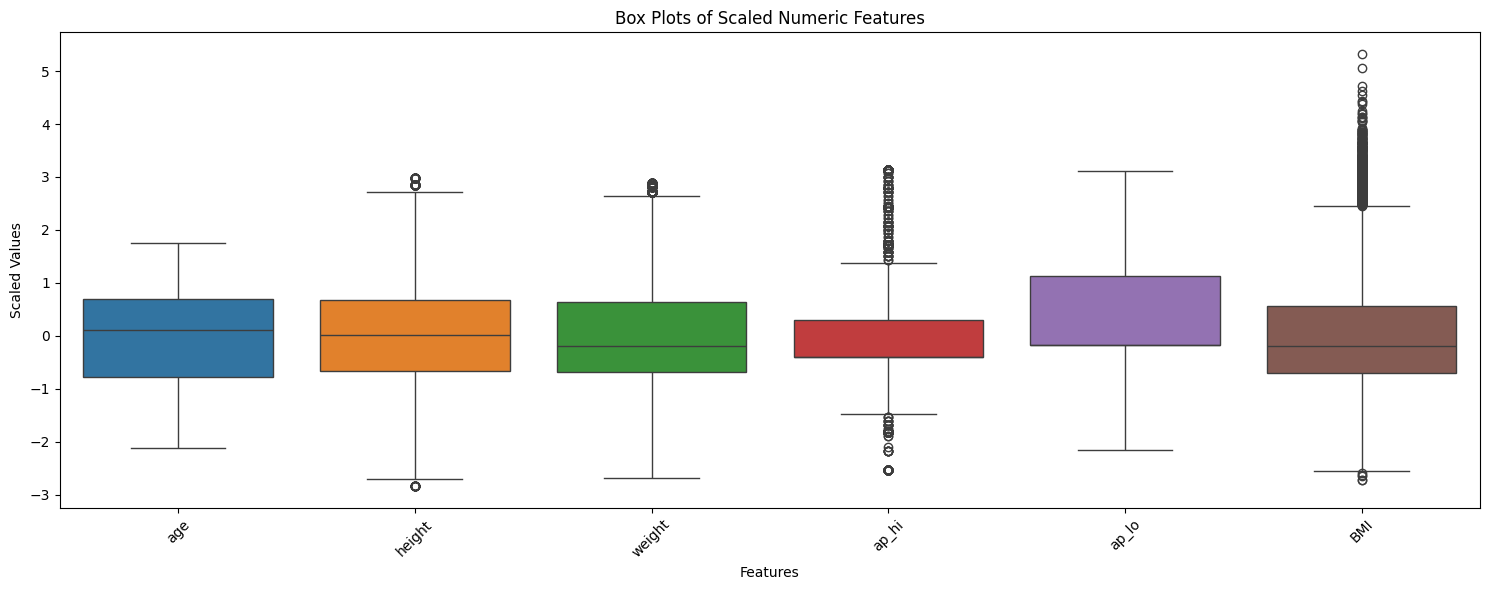

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set figure size
plt.figure(figsize=(15, 6))

# Create box plot using seaborn
sns.boxplot(data=df_scaled[numeric_columns])

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add title and labels
plt.title('Box Plots of Scaled Numeric Features')
plt.xlabel('Features')
plt.ylabel('Scaled Values')

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show the plot
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
import joblib

import warnings
warnings.filterwarnings('ignore')

Preprocessing & Train/Test **Split**

In [ ]:
X = df.drop(columns=['Outcome'])
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (614, 8), Test: (154, 8)


Build **Pipelines**

In [ ]:
# Preprocessing steps: impute missing values, then scale
preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Linear Regression Pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

In [ ]:
lr_pipeline

Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                 ('scaler', StandardScaler())])),
                ('model', LinearRegression())])

Train & **Evaluate**

In [ ]:
def evaluate(name, pipeline, X_train, y_train, X_test, y_test):
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    print(f"{'='*40}")
    print(f"Model : {name}")
    print(f"MAE   : {mae:.3f}")
    print(f"RMSE  : {rmse:.3f}")
    print(f"R²    : {r2:.3f}")
    return preds

lr_preds = evaluate('Linear Regression', lr_pipeline, X_train, y_train, X_test, y_test)

Model : Linear Regression
MAE   : 0.348
RMSE  : 0.414
R²    : 0.255


Visualise **Predictions**

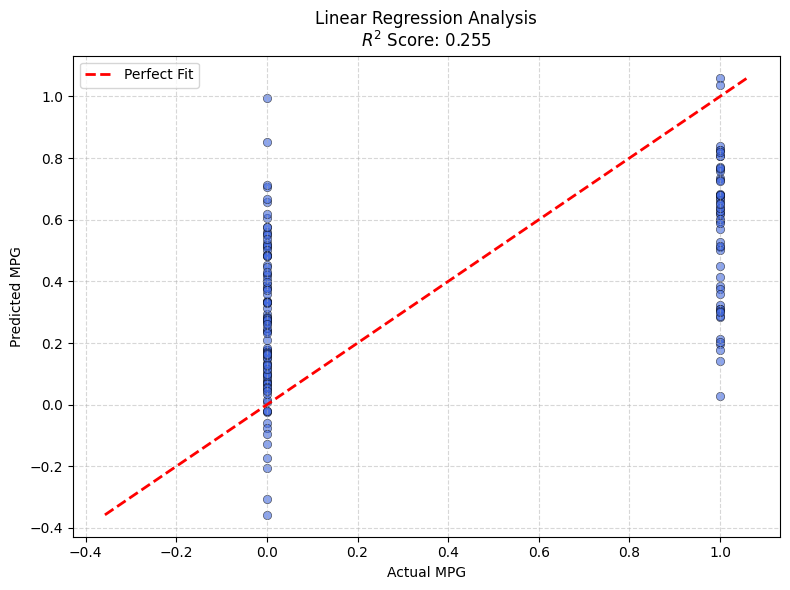

In [ ]:
import matplotlib.pyplot as plt

# 1. Fit and Predict using only the Linear Regression pipeline
lr_pipeline.fit(X_train, y_train)
preds = lr_pipeline.predict(X_test)
r2_score = lr_pipeline.score(X_test, y_test)

# 2. Create the plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, preds, alpha=0.6, edgecolors='k', linewidths=0.5, color='royalblue')

# 3. Draw the "Perfect Prediction" line
# This represents where the dots would be if the model was 100% accurate
lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
plt.plot(lims, lims, 'r--', lw=2, label='Perfect Fit')

# 4. Labels, Title (with R²), and Legend
plt.xlabel('Actual MPG')
plt.ylabel('Predicted MPG')
plt.title(f'Linear Regression Analysis\n$R^2$ Score: {r2_score:.3f}')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5) # Added a light grid for better readability

plt.tight_layout()
plt.show()

In [ ]:
import joblib
from sklearn.metrics import r2_score

# 1. Fit and Predict using only the Linear Regression pipeline
lr_pipeline.fit(X_train, y_train)
preds = lr_pipeline.predict(X_test)

# 2. Evaluate performance
score = r2_score(y_test, preds)

# 3. Save the model to a file
joblib.dump(lr_pipeline, 'linear_regression_model.pkl')

print("Linear Regression Analysis Complete")
print("-" * 30)
print(f"R² Score: {score:.4f}")
print("Model saved to: linear_regression_model.pkl")

Linear Regression Analysis Complete
------------------------------
R² Score: 0.2550
Model saved to: linear_regression_model.pkl
